# 50 — Big bees, small bees, and what the network can see

A network can only use what it can see around a pixel. That area is the
receptive field. Here we measure it, then train a small one and a big one.

In [58]:
from pathlib import Path

import numpy as np
import tifffile
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from tnia.plotting.plt_helper import imshow_multi2d, mask_outline_overlay

from skop.runner import Runner
from skop.ops.segment.stardist2d import stardist2d_custom
from skop.ops.train import extent, receptive_field_stardist2d, train_stardist2d

runner = Runner()
DATA = Path('data/bees/labels')

big_img = tifffile.imread(DATA / 'input0' / 'comb_03_00000.tif')
big_lbl = tifffile.imread(DATA / 'truth0' / 'comb_03_00000.tif')
small_img = tifffile.imread(DATA / 'input0' / 'comb_05_00000.tif')
small_lbl = tifffile.imread(DATA / 'truth0' / 'comb_05_00000.tif')

BIG_BEE = np.median([p.axis_major_length for p in regionprops(big_lbl)])
SMALL_BEE = np.median([p.axis_major_length for p in regionprops(small_lbl)])
print(f'big bees   {BIG_BEE:.0f} px   ({big_lbl.max()} of them)')
print(f'small bees {SMALL_BEE:.0f} px   ({small_lbl.max()} of them)')

big bees   282 px   (21 of them)
small bees 69 px   (97 of them)


In [59]:
# scikit-ops is in heavy development, so for now it is worth "ensuring" the
# environment each time -- check it is up to date, rebuild it if not.
runner.ensure_environment('stardist-tf')

stardist-tf: up to date


<appose.builder.BaseBuilder._create_env.<locals>.BuiltEnvironment at 0x78f11c110380>

## Measure the receptive field

Send one bright pixel through the network. How far the response spreads is
what the network can see. Training does not change this. The shape does.

In [69]:
# The two architectures, set once and used everywhere below.
SMALL_GRID, SMALL_DEPTH = 1, 2 
BIG_GRID, BIG_DEPTH = 2, 4

small_net_field = min(extent(runner.run(
    receptive_field_stardist2d,
    grid_size_xy=SMALL_GRID,
    unet_n_depth=SMALL_DEPTH,
    n_channel_in=3,
    img_size=512,
)))
print(f'grid={SMALL_GRID} depth={SMALL_DEPTH} -> {small_net_field} px')

grid=1 depth=2 -> 46 px


In [70]:
# Deeper, and a coarser grid. Both make the field wider.
big_net_field = min(extent(runner.run(
    receptive_field_stardist2d,
    grid_size_xy=BIG_GRID,
    unet_n_depth=BIG_DEPTH,
    n_channel_in=3,
    img_size=512,
)))
print(f'grid={BIG_GRID} depth={BIG_DEPTH} -> {big_net_field} px')

grid=2 depth=4 -> 366 px


In [71]:
for name, field in [(f'grid={SMALL_GRID} depth={SMALL_DEPTH}', small_net_field),
                    (f'grid={BIG_GRID} depth={BIG_DEPTH}', big_net_field)]:
    print(f'{name}: {field} px  '
          f'small bee {field / SMALL_BEE:.1f}x  big bee {field / BIG_BEE:.1f}x')

grid=1 depth=2: 46 px  small bee 0.7x  big bee 0.2x
grid=2 depth=4: 366 px  small bee 5.3x  big bee 1.3x


## See it on the bees

The red square is what the network sees. Compare it to the bee under it.

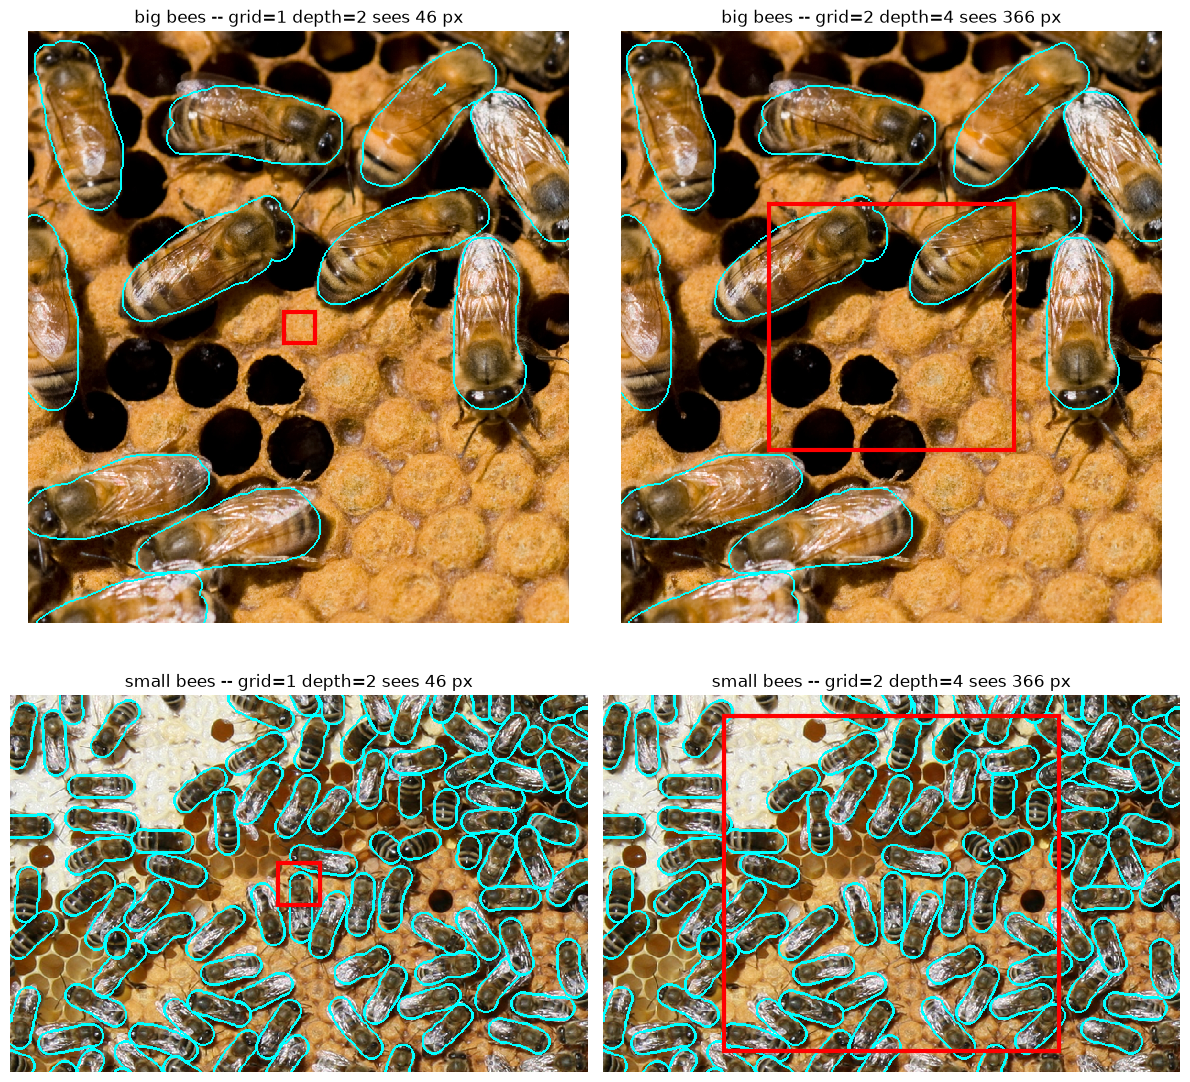

In [72]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
for row, (img, lbl, label) in enumerate([(big_img, big_lbl, 'big bees'),
                                         (small_img, small_lbl, 'small bees')]):
    cy, cx = img.shape[0] // 2, img.shape[1] // 2
    for col, (field, name) in enumerate([(small_net_field, f'grid={SMALL_GRID} depth={SMALL_DEPTH}'),
                                         (big_net_field, f'grid={BIG_GRID} depth={BIG_DEPTH}')]):
        a = ax[row][col]
        a.imshow(mask_outline_overlay(img, lbl))
        a.add_patch(Rectangle((cx - field / 2, cy - field / 2), field, field,
                              fill=False, edgecolor='red', linewidth=3))
        a.set_title(f'{label} -- {name} sees {field} px')
        a.axis('off')
plt.tight_layout()
plt.show()

## Cut patches to train on

Three crops of the big bees, two of the small. Training takes lists of file
paths, so they go to disk.

In [73]:
WORK = Path('/tmp/i2k_bees')
(WORK / 'input').mkdir(parents=True, exist_ok=True)
(WORK / 'truth').mkdir(parents=True, exist_ok=True)

SIZE = 384
crops = [(big_img, big_lbl, 224, 416), (big_img, big_lbl, 64, 128),
         (big_img, big_lbl, 480, 160), (small_img, small_lbl, 0, 224),
         (small_img, small_lbl, 0, 32)]

images, truths = [], []
for i, (img, lbl, y, x) in enumerate(crops):
    crop = img[y:y + SIZE, x:x + SIZE].astype(np.float32)
    lo, hi = np.percentile(crop, (1, 99.8))
    tifffile.imwrite(WORK / 'input' / f'{i:03d}.tif',
                     np.clip((crop - lo) / (hi - lo), 0, 1))
    tifffile.imwrite(WORK / 'truth' / f'{i:03d}.tif',
                     lbl[y:y + SIZE, x:x + SIZE].astype(np.uint16))
    images.append(str(WORK / 'input' / f'{i:03d}.tif'))
    truths.append(str(WORK / 'truth' / f'{i:03d}.tif'))

# Validate on the training data. val_loss then tracks training fit, which is
# what drives the learning rate schedule and picks the saved weights.").splitlines(keepends=True)
train_images = images + images
train_truths = truths + truths
VAL = len(images)

print(len(images), 'pairs,', VAL, 'of them repeated for validation')

5 pairs, 5 of them repeated for validation


## Train the small network

In [74]:
# Retire the worker: ipykernel binds a thread's output to the execution that
# created it, so a reused worker prints the first run only.
runner.close()

def show(ev):
    print(f'{ev.current}/{ev.maximum}  {ev.message}', flush=True)

small_net = runner.run(
    train_stardist2d,
    images=train_images,
    labels=train_truths,
    model_dir=str(WORK / 'models'),
    name='small_net',
    image_axes='YXC',
    grid_size_xy=SMALL_GRID,
    unet_n_depth=SMALL_DEPTH,
    train_patch_size=384,
    train_batch_size=1,
    epochs=100,
    steps_per_epoch=50,
    val_size=VAL,
    on_progress=show,
)
print(small_net)

None/None  None
0/10  Reading 10 pairs
1/None  None
2/None  None
3/None  None
4/None  None
5/None  None
6/None  None
7/None  None
8/None  None
9/None  None
10/None  None
0/100  Training small_net: 5 train, 5 val, 100 epochs
1/100  Epoch 1/100 — loss 9.8488, val_loss 9.4236
2/100  Epoch 2/100 — loss 7.2080, val_loss 5.9220
3/100  Epoch 3/100 — loss 5.6626, val_loss 5.3326
4/100  Epoch 4/100 — loss 5.3452, val_loss 5.1641
5/100  Epoch 5/100 — loss 5.2510, val_loss 5.0290
6/100  Epoch 6/100 — loss 5.0366, val_loss 5.0238
7/100  Epoch 7/100 — loss 5.0935, val_loss 4.9180
8/100  Epoch 8/100 — loss 4.9574, val_loss 4.9230
9/100  Epoch 9/100 — loss 4.9030, val_loss 4.8548
10/100  Epoch 10/100 — loss 4.8418, val_loss 4.8025
11/100  Epoch 11/100 — loss 4.8080, val_loss 4.7246
12/100  Epoch 12/100 — loss 4.8313, val_loss 4.8063
13/100  Epoch 13/100 — loss 4.7674, val_loss 4.6771
14/100  Epoch 14/100 — loss 4.7633, val_loss 4.6659
15/100  Epoch 15/100 — loss 4.6620, val_loss 4.6022
16/100  Epoch 

## Train the big network

In [75]:
runner.close()

big_net = runner.run(
    train_stardist2d,
    images=train_images,
    labels=train_truths,
    model_dir=str(WORK / 'models'),
    name='big_net',
    image_axes='YXC',
    grid_size_xy=BIG_GRID,
    unet_n_depth=BIG_DEPTH,
    train_patch_size=384,
    train_batch_size=1,
    epochs=100,
    steps_per_epoch=50,
    val_size=VAL,
    on_progress=show,
)
print(big_net)

None/None  None
0/10  Reading 10 pairs
1/None  None
2/None  None
3/None  None
4/None  None
5/None  None
6/None  None
7/None  None
8/None  None
9/None  None
10/None  None
0/100  Training big_net: 5 train, 5 val, 100 epochs
1/100  Epoch 1/100 — loss 9.8872, val_loss 9.7008
2/100  Epoch 2/100 — loss 7.8645, val_loss 5.8970
3/100  Epoch 3/100 — loss 5.8233, val_loss 5.1993
4/100  Epoch 4/100 — loss 5.2810, val_loss 5.0092
5/100  Epoch 5/100 — loss 4.9207, val_loss 4.7543
6/100  Epoch 6/100 — loss 4.8728, val_loss 4.6794
7/100  Epoch 7/100 — loss 4.9219, val_loss 4.7600
8/100  Epoch 8/100 — loss 4.7573, val_loss 4.5590
9/100  Epoch 9/100 — loss 4.6158, val_loss 4.5985
10/100  Epoch 10/100 — loss 4.4564, val_loss 4.4376
11/100  Epoch 11/100 — loss 4.4061, val_loss 4.4723
12/100  Epoch 12/100 — loss 4.6563, val_loss 4.4978
13/100  Epoch 13/100 — loss 3.8262, val_loss 3.3683
14/100  Epoch 14/100 — loss 4.1003, val_loss 3.7802
15/100  Epoch 15/100 — loss 3.5910, val_loss 4.0933
16/100  Epoch 16

## Predict on the big bees

Both networks, same image, same settings.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


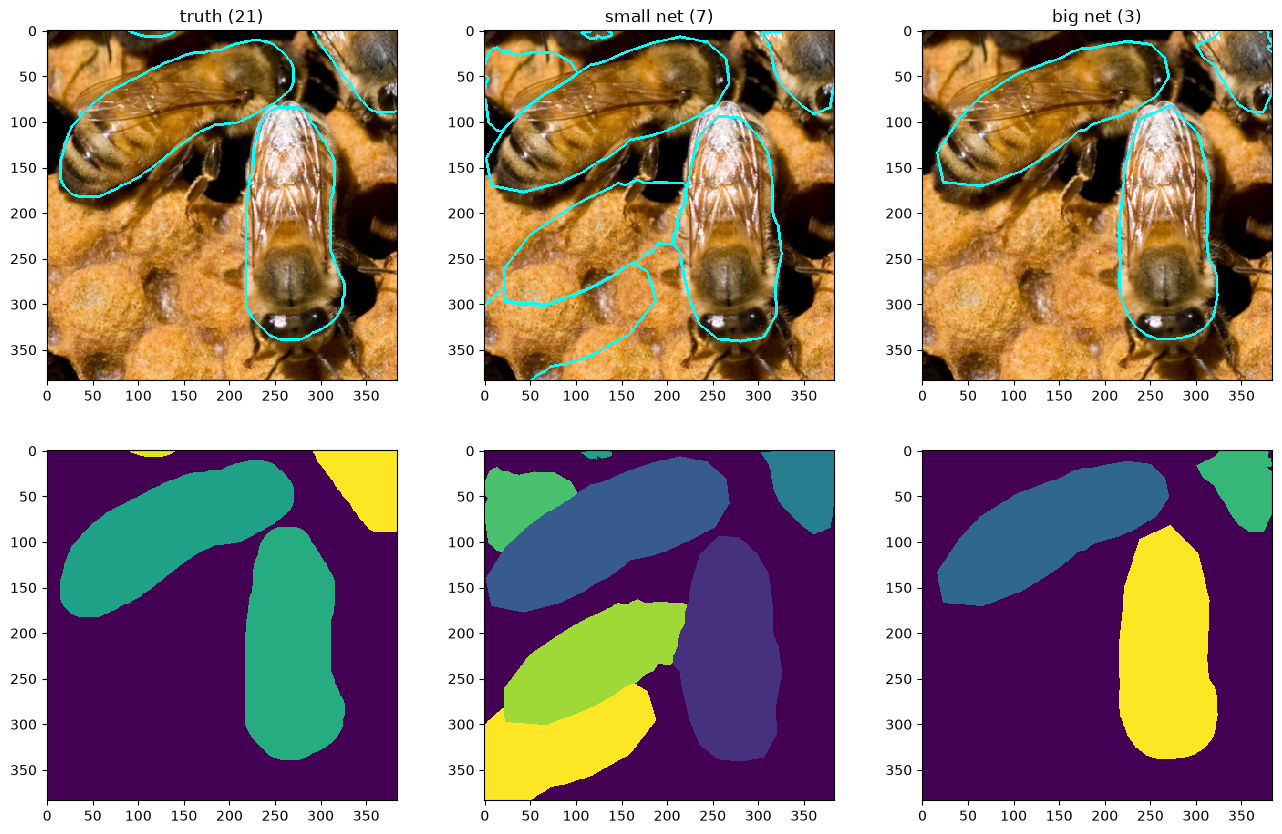

In [76]:
big_patch = tifffile.imread(images[0])
big_truth = tifffile.imread(truths[0])

big_by_small_net = runner.run(stardist2d_custom, image=big_patch,
                              model_dir=small_net, normalize=False)
big_by_big_net = runner.run(stardist2d_custom, image=big_patch,
                            model_dir=big_net, normalize=False)

fig = imshow_multi2d(
    [mask_outline_overlay(big_patch, big_truth),
     mask_outline_overlay(big_patch, big_by_small_net),
     mask_outline_overlay(big_patch, big_by_big_net),
     big_truth, big_by_small_net, big_by_big_net],
    [f'truth ({big_truth.max()})',
     f'small net ({big_by_small_net.max()})',
     f'big net ({big_by_big_net.max()})', '', '', ''],
    2, 3, width=16, height=10,
)

## Predict on the small bees

The small network can see a whole small bee, so this is the fair case for it.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


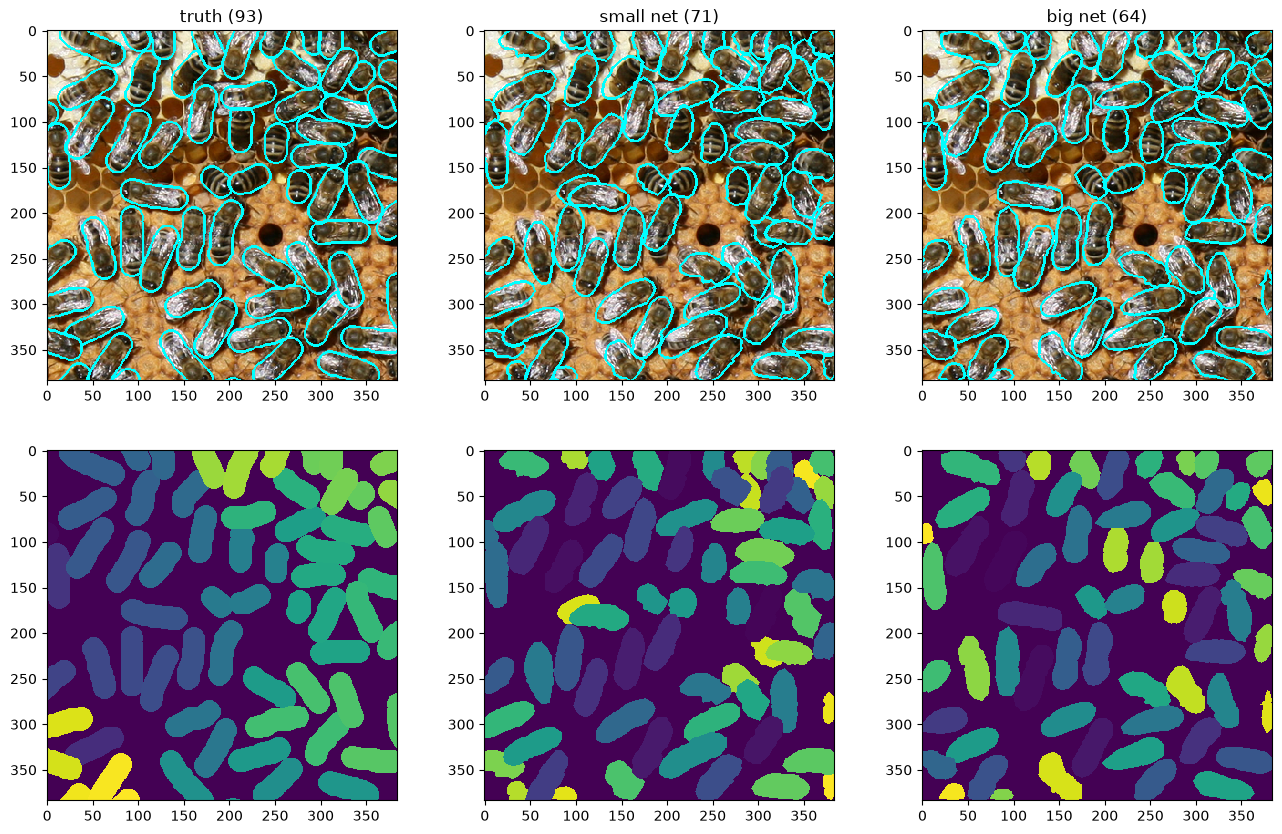

In [77]:
small_patch = tifffile.imread(images[3])
small_truth = tifffile.imread(truths[3])

small_by_small_net = runner.run(stardist2d_custom, image=small_patch,
                                model_dir=small_net, normalize=True)
small_by_big_net = runner.run(stardist2d_custom, image=small_patch,
                              model_dir=big_net, normalize=True)

fig = imshow_multi2d(
    [mask_outline_overlay(small_patch, small_truth),
     mask_outline_overlay(small_patch, small_by_small_net),
     mask_outline_overlay(small_patch, small_by_big_net),
     small_truth, small_by_small_net, small_by_big_net],
    [f'truth ({small_truth.max()})',
     f'small net ({small_by_small_net.max()})',
     f'big net ({small_by_big_net.max()})', '', '', ''],
    2, 3, width=16, height=10,
)

## Now on parts of the same images we never trained on

No ground truth here. We are asking whether the networks learned bees, or
just memorised the patches.

In [ ]:
# The bottom-right corner of comb_03, well outside the labelled area.
from skimage.io import imread

big_unseen = imread('data/bees/comb_03.png')[-512:, -512:, :3]

big_unseen_small_net = runner.run(stardist2d_custom, image=big_unseen,
                                  model_dir=small_net, normalize=True)
big_unseen_big_net = runner.run(stardist2d_custom, image=big_unseen,
                                model_dir=big_net, normalize=True)

imshow_multi2d(
    [big_unseen,
     mask_outline_overlay(big_unseen, big_unseen_small_net),
     mask_outline_overlay(big_unseen, big_unseen_big_net)],
    ['big bees, never trained on',
     f'small net ({big_unseen_small_net.max()})',
     f'big net ({big_unseen_big_net.max()})'],
    1, 3, width=17, height=6,
)

In [ ]:
# The same corner of comb_05.
small_unseen = imread('data/bees/comb_05.png')[-512:, -512:, :3]

small_unseen_small_net = runner.run(stardist2d_custom, image=small_unseen,
                                    model_dir=small_net, normalize=True)
small_unseen_big_net = runner.run(stardist2d_custom, image=small_unseen,
                                  model_dir=big_net, normalize=True)

imshow_multi2d(
    [small_unseen,
     mask_outline_overlay(small_unseen, small_unseen_small_net),
     mask_outline_overlay(small_unseen, small_unseen_big_net)],
    ['small bees, never trained on',
     f'small net ({small_unseen_small_net.max()})',
     f'big net ({small_unseen_big_net.max()})'],
    1, 3, width=17, height=6,
)

## What to take away

Match the field to the object. A field smaller than the object cannot see the
edges, so it guesses the size instead of measuring it.